# Practice 1 - CNNs: Part 1 - Custom CNNs

**Authors:** [Name 1], [Name 2]

**Date:** March 2026

**Description:** In this notebook we develop several custom convolutional neural network (CNN) models to solve the classification problem posed by the STL-10 dataset.

---
## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Dataset Loading & Exploration](#2-dataset-loading--exploration)
3. [Data Preprocessing](#3-data-preprocessing)
4. [Data Augmentation](#4-data-augmentation)
5. [Baseline CNN Model](#5-baseline-cnn-model)
6. [Improved CNN Model](#6-improved-cnn-model)
7. [Advanced Architecture: Residual Network](#7-advanced-architecture-residual-network)
8. [Advanced Architecture: Inception / Xception](#8-advanced-architecture-inception--xception)
9. [Results Comparison](#9-results-comparison)
10. [Conclusions](#10-conclusions)

---
## 1. Setup & Imports

docker run -d --gpus all --ipc=host --name tensorflow-server -p 8888:8888 -v /home/grey/USC/DL/DL_project:/workspace nvcr.io/nvidia/tensorflow:25.02-tf2-py3 jupyter lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root

In [1]:
%pip install matplotlib
%pip install tensorflow-datasets
%pip install importlib_resources
%pip install keras_cv
%pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
import keras_cv
from keras import layers, Model, regularizers
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-03-24 23:53:53.948325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 23:53:54.061238: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 23:53:54.098357: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-24 23:53:54.260562: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Using TensorFlow backend


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.17.0
Keras version: 3.3.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1774396438.897293     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774396439.327203     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774396439.327247     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Constants
IMG_SIZE = 96        # STL-10 native resolution
NUM_CLASSES = 10
BATCH_SIZE = 32
EPOCHS = 50          # Adjust as needed
VALIDATION_SPLIT = 0.2

# Directory to save models
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

---
## 2. Dataset Loading & Exploration

The **STL-10** dataset contains:
- 5,000 labeled training images (500 per class)
- 8,000 labeled test images (800 per class)
- 100,000 unlabeled images (not used here)
- Image size: 96×96 pixels, 3 color channels (RGB)
- 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck

In [4]:
# Load STL-10 from TensorFlow Datasets
(ds_train, ds_test), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

print(ds_info)

tfds.core.DatasetInfo(
    name='stl10',
    full_name='stl10/1.0.0',
    description="""
    The STL-10 dataset is an image recognition dataset for developing unsupervised
    feature learning, deep learning, self-taught learning algorithms. It is inspired
    by the CIFAR-10 dataset but with some modifications. In particular, each class
    has fewer labeled training examples than in CIFAR-10, but a very large set of
    unlabeled examples is provided to learn image models prior to supervised
    training. The primary challenge is to make use of the unlabeled data (which
    comes from a similar but different distribution from the labeled data) to build
    a useful prior. All images were acquired from labeled examples on ImageNet.
    """,
    homepage='http://ai.stanford.edu/~acoates/stl10/',
    data_dir='/root/tensorflow_datasets/stl10/1.0.0',
    file_format=tfrecord,
    download_size=2.46 GiB,
    dataset_size=1.86 GiB,
    features=FeaturesDict({
        'image': Image(shape=

I0000 00:00:1774396439.836762     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774396439.836808     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774396439.836818     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774396440.067734     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774396440.067873     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-24

In [5]:
# Class names
class_names = ds_info.features['label'].names
print(f"Classes: {class_names}")
print(f"Number of training samples: {ds_info.splits['train'].num_examples}")
print(f"Number of test samples: {ds_info.splits['test'].num_examples}")

Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Number of training samples: 5000
Number of test samples: 8000


2026-03-24 23:54:00.373644: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


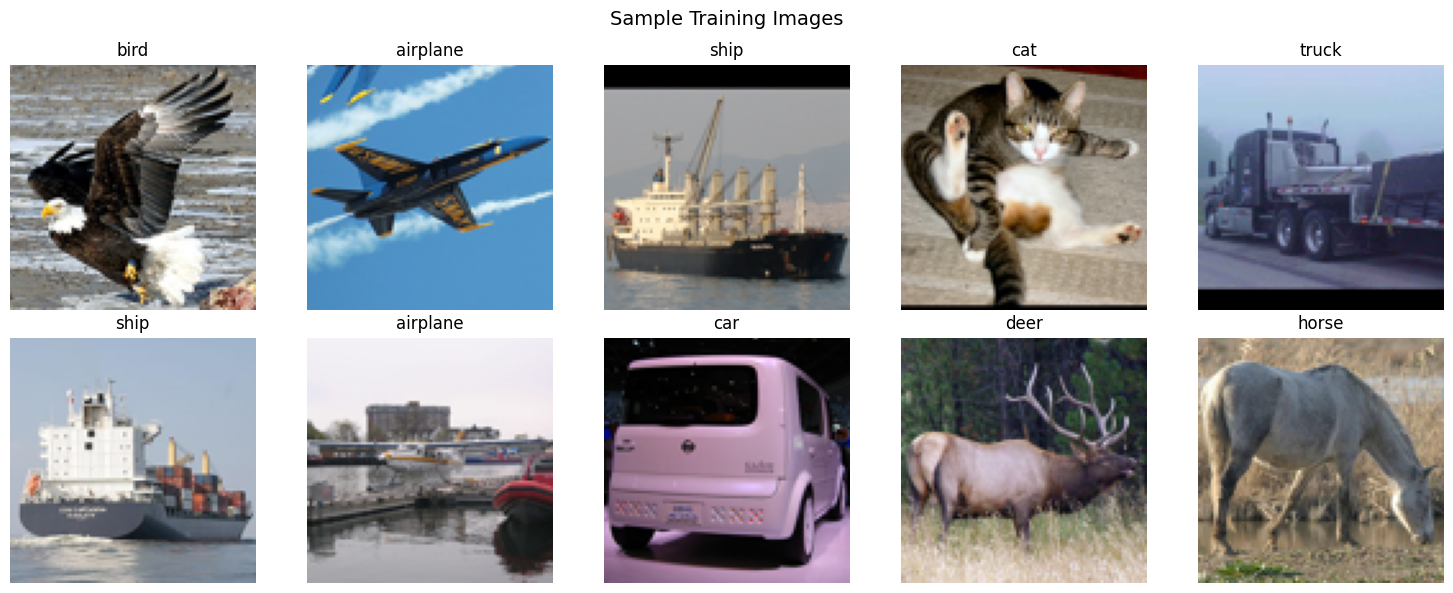

In [6]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, (image, label) in enumerate(ds_train.take(10)):
    ax = axes[i // 5, i % 5]
    ax.imshow(image.numpy())
    ax.set_title(class_names[label.numpy()])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

2026-03-24 23:54:01.146235: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


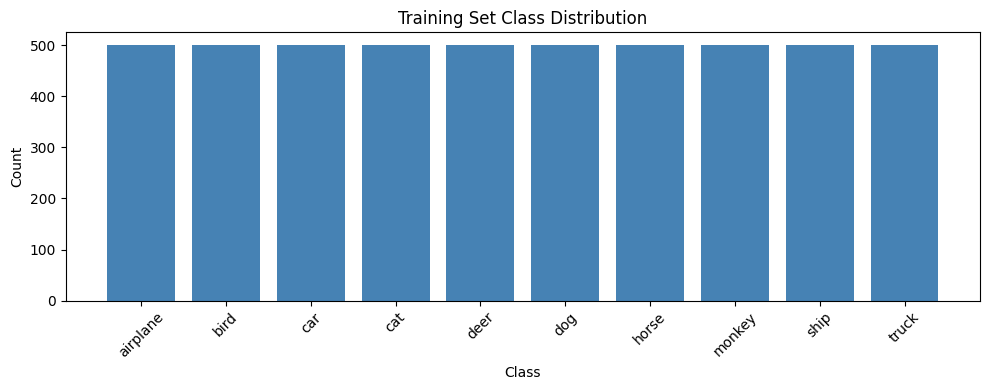

In [7]:
# Check class distribution
train_labels = [label.numpy() for _, label in ds_train]
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[u] for u in unique], counts, color='steelblue')
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

Steps:
- Normalize pixel values to [0, 1]
- Resize images if needed (STL-10 is already 96×96)
- Create a validation split from the training set
- Build efficient `tf.data` pipelines with prefetching

In [8]:
def preprocess(image, label):
    """Normalize images to [0, 1] and resize."""
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

In [9]:
# Total training samples
num_train = ds_info.splits['train'].num_examples
num_val = int(num_train * VALIDATION_SPLIT)
num_train_actual = num_train - num_val

print(f"Training samples: {num_train_actual}")
print(f"Validation samples: {num_val}")

# Shuffle and split into train/validation
ds_train_shuffled = ds_train.shuffle(num_train, seed=SEED)

ds_val = ds_train_shuffled.take(num_val)
ds_train_split = ds_train_shuffled.skip(num_val)

# Apply preprocessing and batching
train_dataset = (
    ds_train_split
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(num_train_actual)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    ds_val
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

Training samples: 4000
Validation samples: 1000


''+ptx85' is not a recognized feature for this target (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

In [10]:
# Verify shapes
for images, labels in train_dataset.take(1):
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"Pixel value range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Batch images shape: (32, 96, 96, 3)
Batch labels shape: (32,)
Pixel value range: [0.00, 1.00]


---
## 4. Data Augmentation

To combat overfitting (especially with only ~4,000 training samples), we define data augmentation layers that will be embedded in the model and only active during training.

In [11]:
data_augmentation_low = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
], name="data_augmentation_low")

In [12]:
@keras.saving.register_keras_serializable()
class CustomColorJitter(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs, training=True):
        # Augmentations should ONLY apply during training
        if training:
            # Shift hue by a random factor
            x = tf.image.random_hue(inputs, 0.1)
            # Shift saturation
            x = tf.image.random_saturation(x, lower=0.8, upper=1.2)
            # Brightness and contrast
            x = tf.image.random_brightness(x, 0.2)
            x = tf.image.random_contrast(x, lower=0.8, upper=1.2)
            return x
        else:
            return inputs

In [13]:
data_augmentation_big = keras.Sequential([ 
    # Horizontally flip the image (valid for STL-10 classes like cars, animals)
    layers.RandomFlip("horizontal"), 
    
    # Kept slightly lower than 0.1 (0.05 = ~18 degrees) to prevent unrealistic angles
    # Added "reflect" so empty pixels are filled naturally instead of with black blocks
    layers.RandomRotation(factor=0.05, fill_mode="reflect"), 
    
    # 10% shift on X and Y axes builds spatial invariance
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="reflect"), 
    
    # 10% zoom in/out builds scale invariance
    layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="reflect"), 
    
    # Adds lighting variance so the model doesn't memorize brightness/shadows
    layers.RandomContrast(factor=0.2),

    # CustomColorJitter() # Your custom layer goes here
], name="data_augmentation_big")

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

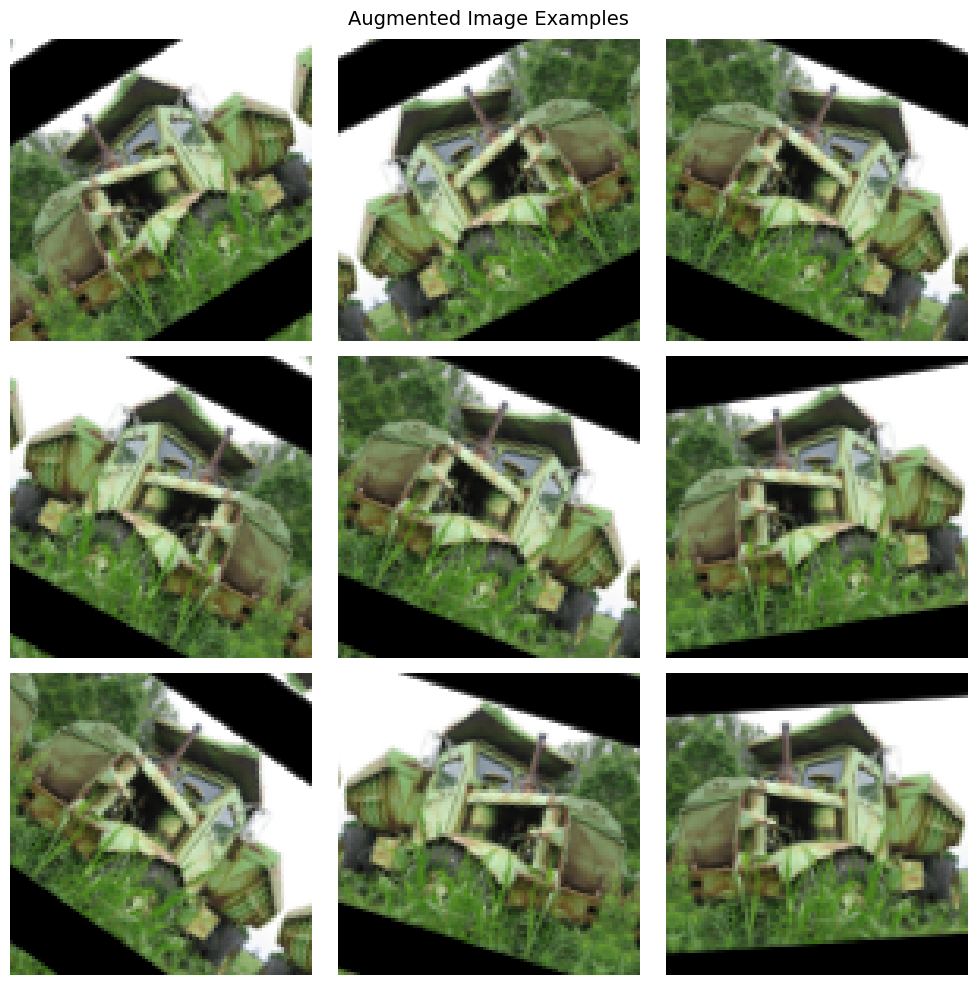

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

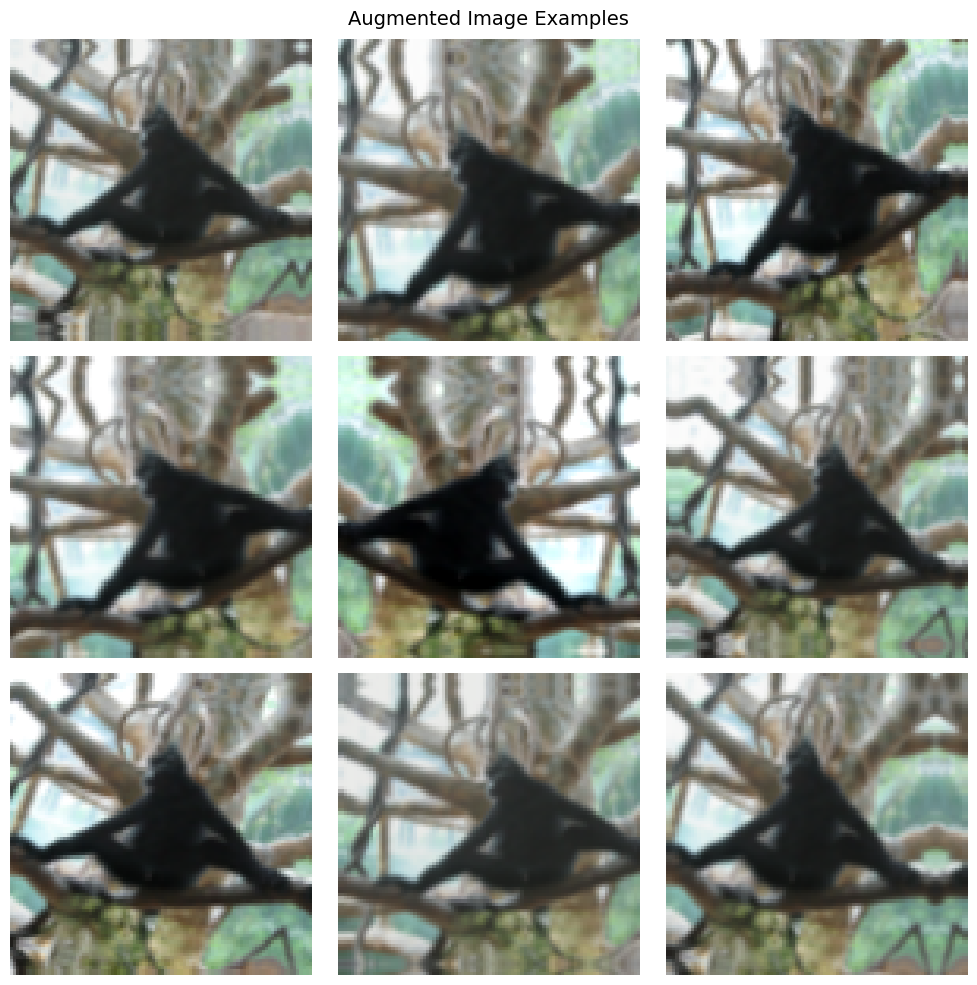

In [14]:
# Visualize augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation_low(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy())
        plt.axis('off')
plt.suptitle('Augmented Image Examples', fontsize=14)
plt.tight_layout()
plt.show()

# Visualize augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation_big(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy())
        plt.axis('off')
plt.suptitle('Augmented Image Examples', fontsize=14)
plt.tight_layout()
plt.show()

---
## Helper Functions

Utility functions for training, evaluation, and plotting that will be reused across models.

In [15]:
def plot_history(history, title=""):
    """Plot training and validation accuracy and loss curves."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
    ax1.plot(epochs_range, val_acc, 'r--o', label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0.0, 1.0])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, loss, 'b-o', label='Training Loss')
    ax2.plot(epochs_range, val_loss, 'r--o', label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
def train_and_evaluate(model, model_name, train_ds, val_ds, test_ds, epochs=EPOCHS):
    """Train a model, plot history, evaluate on test set, and return results."""
    
    filepath = os.path.join(MODEL_DIR, f"{model_name}.keras")
    
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=filepath,
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=callbacks
    )

    # Plot training curves
    plot_history(history, title=model_name)

    # Evaluate on test set
    best_model = keras.models.load_model(filepath)
    test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
    print(f"\n{model_name} - Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    return {
        'model_name': model_name,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    }

In [17]:
# Store results for comparison
results = []

---
## 5. Baseline CNN Models

We perform a systematic exploration of simple VGG-style architectures to determine the best depth (number of convolutional blocks). All baselines use **no data augmentation and no regularization** to isolate the effect of architecture depth.

**Experiments:**
1. **Baseline A** — 2 blocks (Conv2D → MaxPooling2D) × 2
2. **Baseline B** — 3 blocks (Conv2D → MaxPooling2D) × 3 *(current default)*
3. **Baseline C** — 4 blocks (Conv2D → MaxPooling2D) × 4
4. **Baseline D** — Best of A/B/C with **2 Conv2D per block** instead of 1

### 5.1 Experiment A — 2 Blocks

The simplest architecture: only 2 convolutional blocks with filters 32 and 64.

In [18]:
def build_baseline_a(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Baseline A: 2 blocks (Conv2D + MaxPooling2D)."""
    inputs = keras.Input(shape=input_shape)
    
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='baseline_a_2blocks')
    return model

baseline_a = build_baseline_a()
baseline_a.summary()

Model: "baseline_a_2blocks"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,739,402 (18.08 MB)

 Trainable params: 4,739,402 (18.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1774396444.998295     270 service.cc:146] XLA service 0x34cd5610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774396444.998338     270 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0
2026-03-24 23:54:05.024374: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-24 23:54:05.291642: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 22/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1174 - loss: 2.5406

I0000 00:00:1774396447.082300     270 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2308 - loss: 2.1179

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 1: val_loss improved from inf to 1.42348, saving model to models/baseline_a_2blocks.keras


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.2349 - loss: 2.1048 - val_accuracy: 0.4630 - val_loss: 1.4235 - learning_rate: 0.0010
Epoch 2/50
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5045 - loss: 1.3202
Epoch 2: val_loss improved from 1.42348 to 1.07742, saving model to models/baseline_a_2blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5052 - loss: 1.3196 - val_accuracy: 0.6320 - val_loss: 1.0774 - learning_rate: 0.0010
Epoch 3/50
120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6823 - loss: 0.9404
Epoch 3: val_loss improved from 1.07742 to 0.74062, saving model to models/baseline_a_2blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6818 - loss: 0.9407 - val_accuracy: 0.7770 - val_loss: 0.7406 - learning_rate: 0.0010
Epoch 4/50
120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8081 - loss: 0.5831
Epoch 4: val_loss improved from 0.74062 to 0.60161, saving model to models/baseline_a_2blocks.keras
125/125 ━━━━━━━━

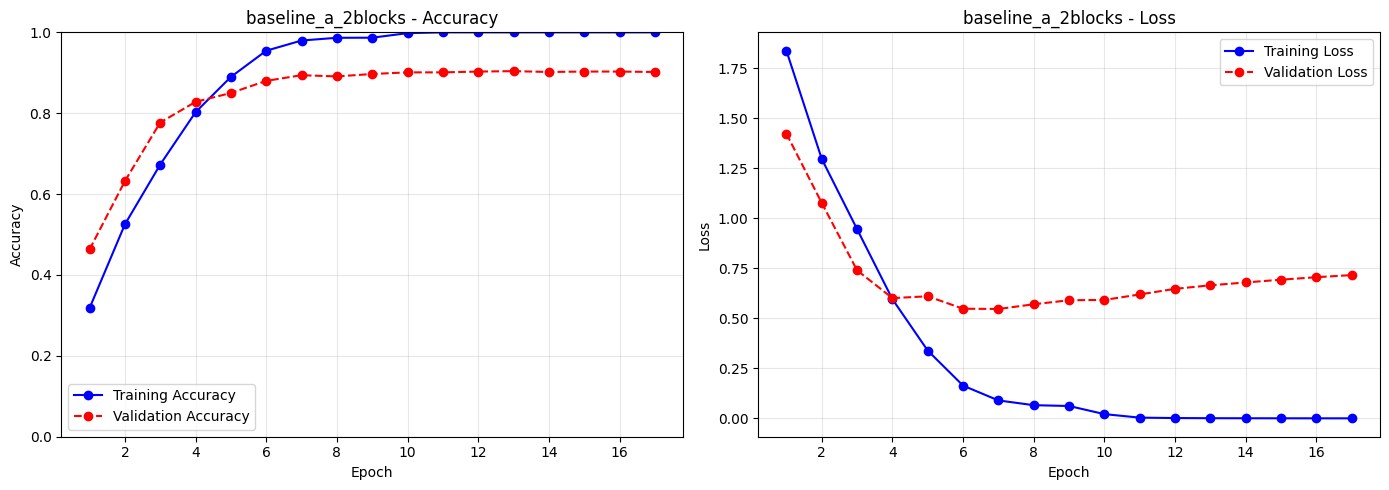

 25/250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4819 - loss: 2.5837

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5103 - loss: 2.5011

baseline_a_2blocks - Test Accuracy: 0.5244, Test Loss: 2.4296


In [19]:
baseline_a.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_a = train_and_evaluate(
    baseline_a, 'baseline_a_2blocks',
    train_dataset, val_dataset, test_dataset
)
results.append(result_a)

**Observations (Baseline A — 2 Blocks):**

_TODO: Comment on the training curves. Is there underfitting due to limited capacity? What test accuracy was achieved?_

### 5.2 Experiment B — 3 Blocks

The default architecture from the course material: 3 convolutional blocks with increasing filters (32 → 64 → 128).

In [20]:
def build_baseline_b(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Baseline B: 3 blocks (Conv2D + MaxPooling2D)."""
    inputs = keras.Input(shape=input_shape)
    
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='baseline_b_3blocks')
    return model

baseline_b = build_baseline_b()
baseline_b.summary()

Model: "baseline_b_3blocks"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,962 (9.36 MB)

 Trainable params: 2,453,962 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.2264 - loss: 2.0377

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 1: val_loss improved from inf to 1.55245, saving model to models/baseline_b_3blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2278 - loss: 2.0340 - val_accuracy: 0.3940 - val_loss: 1.5524 - learning_rate: 0.0010
Epoch 2/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 92/125 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.4652 - loss: 1.4117
Epoch 2: val_loss improved from 1.55245 to 1.24003, saving model to models/baseline_b_3blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4679 - loss: 1.4101 - val_accuracy: 0.5750 - val_loss: 1.2400 - learning_rate: 0.0010
Epoch 3/50
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5839 - loss: 1.1523
Epoch 3: val_loss improved from 1.24003 to 0.98201, saving model to models/baseline_b_3blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5838 - loss: 1.1520 - val_accuracy: 0.6470 - val_loss: 0.9820 - learning_rate: 0.0010
Epoch 4/50
120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6794 - loss: 0.8701
Epoch 4: val_loss improved from 0.98201 to 0.81163, saving model to models/baseline_b_3blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6791 - loss: 0.8718 - val_accuracy: 0.7460 - val_loss: 0.8116 - learning_rate: 0.0010
Epoch 5/50
  4/125 ━━━━━━━━

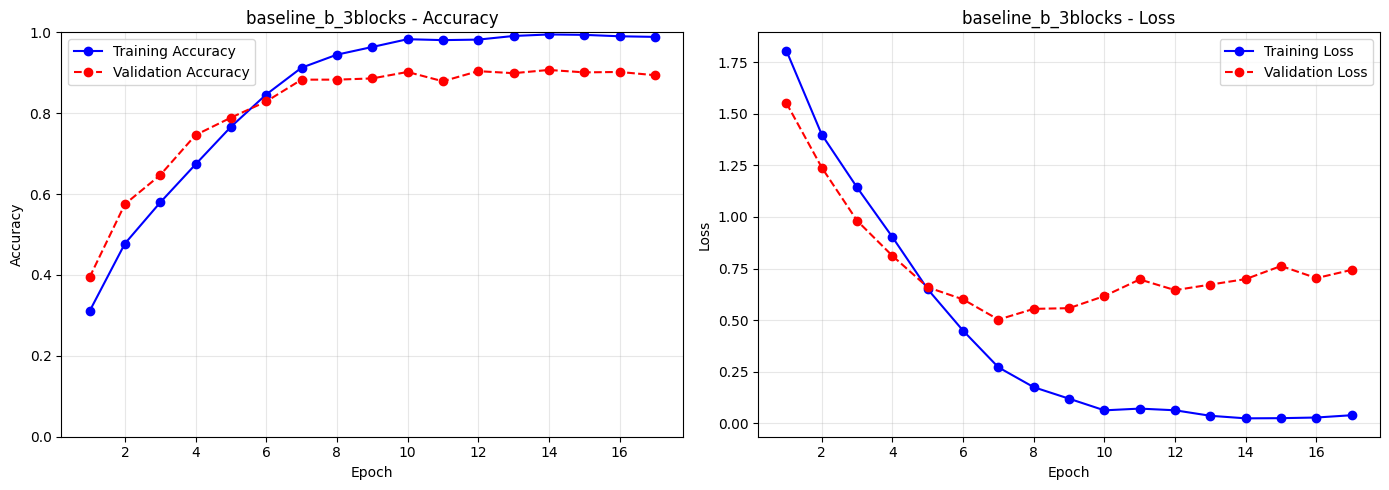

 23/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5314 - loss: 1.9337

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5671 - loss: 1.8521

baseline_b_3blocks - Test Accuracy: 0.5740, Test Loss: 1.8288


In [21]:
baseline_b.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_b = train_and_evaluate(
    baseline_b, 'baseline_b_3blocks',
    train_dataset, val_dataset, test_dataset
)
results.append(result_b)

**Observations (Baseline B — 3 Blocks):**

_TODO: Comment on the training curves. Is there overfitting? Compare with Baseline A — did the extra block help?_

### 5.3 Experiment C — 4 Blocks

A deeper architecture with 4 convolutional blocks (32 → 64 → 128 → 256). More capacity but also more risk of overfitting on our small dataset.

In [22]:
def build_baseline_c(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Baseline C: 4 blocks (Conv2D + MaxPooling2D)."""
    inputs = keras.Input(shape=input_shape)
    
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='baseline_c_4blocks')
    return model

baseline_c = build_baseline_c()
baseline_c.summary()

Model: "baseline_c_4blocks"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,482 (5.99 MB)

 Trainable params: 1,569,482 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2120 - loss: 2.0942

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 1: val_loss improved from inf to 1.61852, saving model to models/baseline_c_4blocks.keras


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.2126 - loss: 2.0927 - val_accuracy: 0.3540 - val_loss: 1.6185 - learning_rate: 0.0010
Epoch 2/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3916 - loss: 1.5522
Epoch 2: val_loss improved from 1.61852 to 1.46104, saving model to models/baseline_c_4blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3921 - loss: 1.5518 - val_accuracy: 0.4480 - val_loss: 1.4610 - learning_rate: 0.0010
Epoch 3/50
  6/125 ━━━━━━━━━━━━━━━━━━━━ 37:52 19s/step - accuracy: 0.4865 - loss: 1.3856
Epoch 3: val_loss improved from 1.46104 to 1.31403, saving model to models/baseline_c_4blocks.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4972 - loss: 1.3585 - val_accuracy: 0.5010 - val_loss: 1.3140 - learning_rate: 0.0010
Epoch 4/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5643 - loss: 1.1857
Epoch 4: val_loss improved from 1.31403 to 1.04191, saving model to models/baseline_c_4blocks.keras
125/125 ━━━━

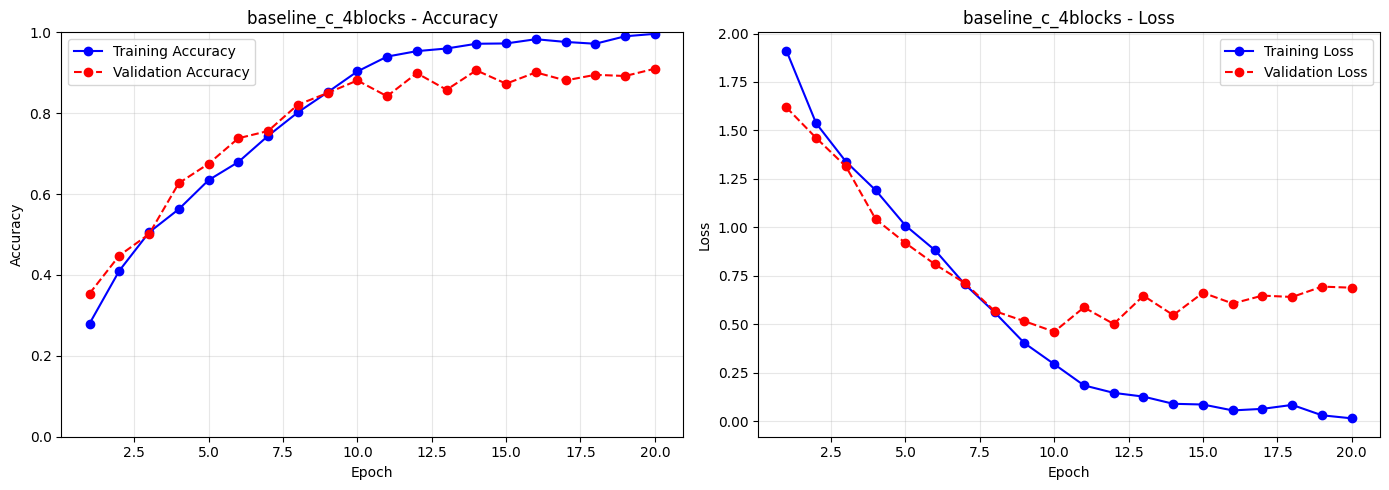

 24/250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5382 - loss: 1.8477

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5620 - loss: 1.7426

baseline_c_4blocks - Test Accuracy: 0.5709, Test Loss: 1.6945


In [23]:
baseline_c.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_c = train_and_evaluate(
    baseline_c, 'baseline_c_4blocks',
    train_dataset, val_dataset, test_dataset
)
results.append(result_c)

**Observations (Baseline C — 4 Blocks):**

_TODO: Comment on the training curves. Did the 4th block improve or worsen results? Is overfitting more pronounced?_

### 5.4 Intermediate Comparison (A vs B vs C)

Baseline Depth Comparison
  baseline_a_2blocks         Test Acc: 0.5244
  baseline_b_3blocks         Test Acc: 0.5740 <-- BEST
  baseline_c_4blocks         Test Acc: 0.5709

Best depth: baseline_b_3blocks


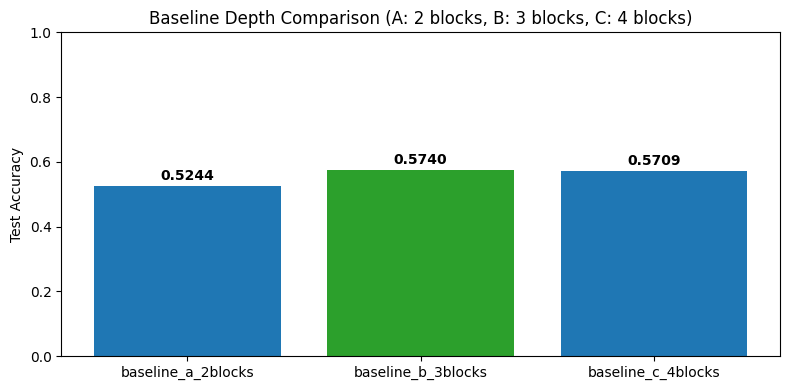

In [24]:
# Compare A, B, C to determine the best depth
baseline_results = [result_a, result_b, result_c]
best_baseline = max(baseline_results, key=lambda r: r['test_accuracy'])

print("="*60)
print("Baseline Depth Comparison")
print("="*60)
for r in baseline_results:
    marker = " <-- BEST" if r == best_baseline else ""
    print(f"  {r['model_name']:25s}  Test Acc: {r['test_accuracy']:.4f}{marker}")
print(f"\nBest depth: {best_baseline['model_name']}")

# Bar chart
names = [r['model_name'] for r in baseline_results]
accs = [r['test_accuracy'] for r in baseline_results]
colors = ['#2ca02c' if r == best_baseline else '#1f77b4' for r in baseline_results]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, accs, color=colors)
plt.ylabel('Test Accuracy')
plt.title('Baseline Depth Comparison (A: 2 blocks, B: 3 blocks, C: 4 blocks)')
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Experiment D — Best Depth with 2 Conv2D per Block

Based on the results above, we take the best-performing depth and add a **second Conv2D layer to each block** (similar to the VGG approach of stacking convolutions before pooling). This increases the receptive field and the model's capacity to learn richer features within each block.

> **Note:** Update the function below to match the winning depth from experiments A/B/C. The code below provides all three variants — **uncomment the one that matches the best result and comment out the others.**

In [25]:
def build_baseline_d(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Baseline D: Best depth from A/B/C but with 2 Conv2D per block.
    
    Uncomment the variant that matches the best depth from the previous comparison.
    """
    inputs = keras.Input(shape=input_shape)
    
    # --- Variant for 4 blocks (if Baseline C won) ---
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='baseline_d_double_conv')
    return model

baseline_d = build_baseline_d()
baseline_d.summary()

Model: "baseline_d_double_conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,353,322 (8.98 MB)

 Trainable params: 2,353,322 (8.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2026-03-24 23:57:09.858506: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,32,96,96]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,96,96]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-24 23:57:09.896119: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1m35.797333787s
Trying algorithm eng0{} for conv (f32[32,32,96,96]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,96,96]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operat

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1419 - loss: 2.2386

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 1: val_loss improved from inf to 1.83336, saving model to models/baseline_d_double_conv.keras


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.1423 - loss: 2.2375 - val_accuracy: 0.2860 - val_loss: 1.8334 - learning_rate: 0.0010
Epoch 2/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step - accuracy: 0.3270 - loss: 1.7273
Epoch 2: val_loss improved from 1.83336 to 1.46648, saving model to models/baseline_d_double_conv.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3277 - loss: 1.7258 - val_accuracy: 0.4260 - val_loss: 1.4665 - learning_rate: 0.0010
Epoch 3/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4188 - loss: 1.5182
Epoch 3: val_loss improved from 1.46648 to 1.40245, saving model to models/baseline_d_double_conv.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4188 - loss: 1.5178 - val_accuracy: 0.4710 - val_loss: 1.4024 - learning_rate: 0.0010
Epoch 4/50
 63/125 ━━━━━━━━━━━━━━━━━━━━ 1:37 2s/step - accuracy: 0.4714 - loss: 1.3917 
Epoch 4: val_loss improved from 1.40245 to 1.32519, saving model to models/baseline_d_double_conv.kera

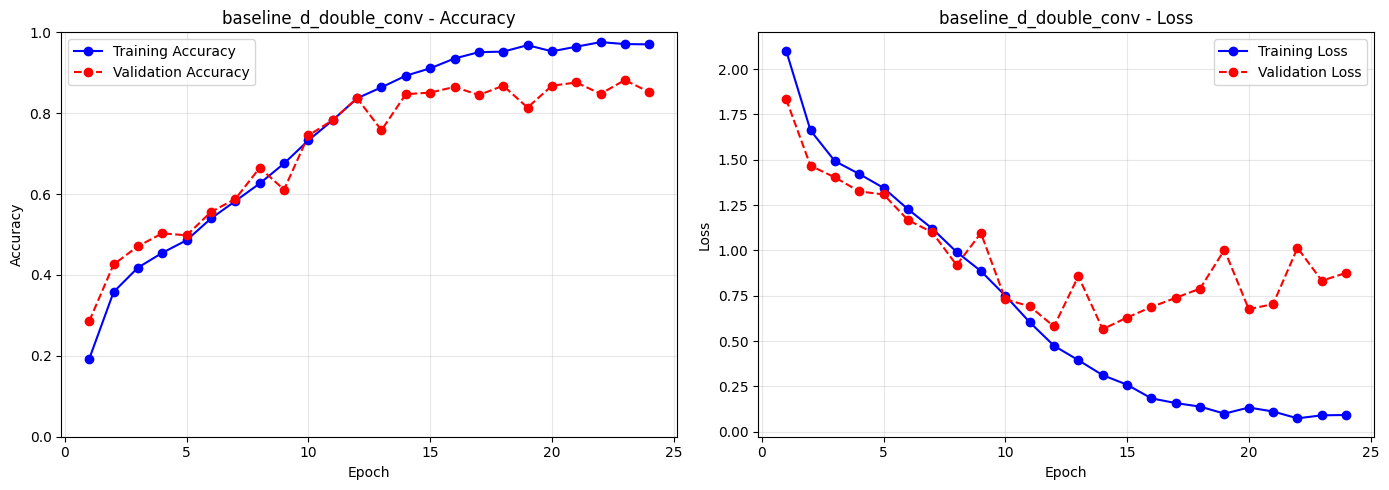

 14/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4720 - loss: 2.1004

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4855 - loss: 2.1774

baseline_d_double_conv - Test Accuracy: 0.4927, Test Loss: 2.1760


In [26]:
baseline_d.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_d = train_and_evaluate(
    baseline_d, 'baseline_d_double_conv',
    train_dataset, val_dataset, test_dataset
)
results.append(result_d)

**Observations (Baseline D — Double Conv2D per Block):**

_TODO: Did adding a second Conv2D per block improve results compared to the single-Conv2D winner? Comment on parameter count increase vs accuracy gain._

### 5.6 Baseline Summary

BASELINE EXPERIMENTS SUMMARY


,Model,Test Accuracy,Test Loss,Best
0,baseline_a_2blocks,0.5244,2.4296,
1,baseline_b_3blocks,0.5740,1.8288,✓
2,baseline_c_4blocks,0.5709,1.6945,
3,baseline_d_double_conv,0.4927,2.1760,


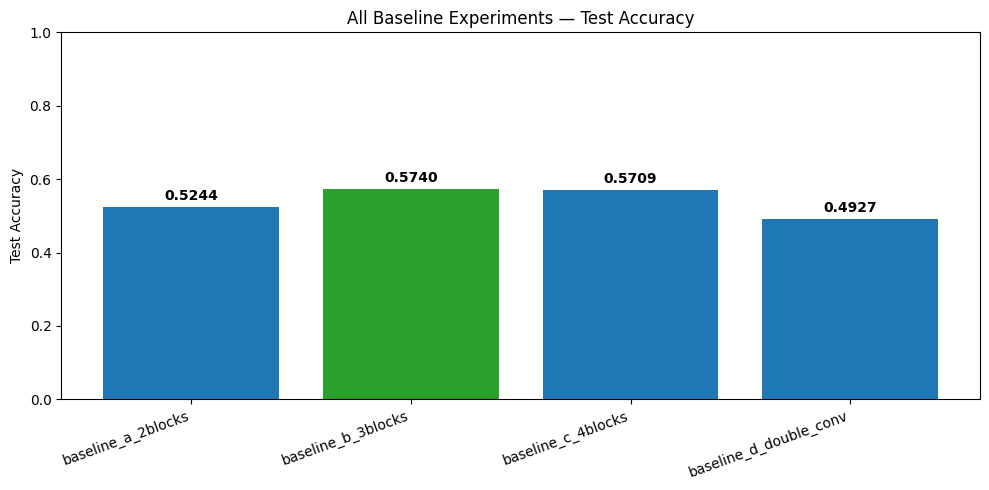


Best baseline model: baseline_b_3blocks (Test Accuracy: 0.5740)


In [27]:
# Summary table of all 4 baseline experiments
import pandas as pd

all_baselines = [result_a, result_b, result_c, result_d]
best_overall = max(all_baselines, key=lambda r: r['test_accuracy'])

baseline_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test Loss': f"{r['test_loss']:.4f}",
        'Best': '✓' if r == best_overall else ''
    }
    for r in all_baselines
])

print("="*60)
print("BASELINE EXPERIMENTS SUMMARY")
print("="*60)
display(baseline_df)

# Bar chart
names = [r['model_name'] for r in all_baselines]
accs = [r['test_accuracy'] for r in all_baselines]
colors = ['#2ca02c' if r == best_overall else '#1f77b4' for r in all_baselines]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, accs, color=colors)
plt.ylabel('Test Accuracy')
plt.title('All Baseline Experiments — Test Accuracy')
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(f"\nBest baseline model: {best_overall['model_name']} "
      f"(Test Accuracy: {best_overall['test_accuracy']:.4f})")

**Overall Baseline Conclusions:**

_TODO: Summarize the baseline experiments:_
- _Which depth (2/3/4 blocks) worked best and why?_
- _Did doubling the Conv2D layers per block help? At what cost (parameters, training time)?_
- _What is the best baseline architecture to carry forward to the next sections (regularization, advanced architectures)?_

---
## 6. Improved CNN Model

Improvements over the baseline:
- **Data augmentation** to increase effective training samples
- **Dropout** for regularization
- **Batch Normalization** for faster convergence
- **Deeper architecture** with more filters

In [43]:
def build_improved_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build an improved CNN with augmentation, batch norm, and dropout."""
    inputs = keras.Input(shape=input_shape)
    
    # Data augmentation (only active during training)
    # x = data_augmentation_low(inputs)
    x = inputs
    
    # Block 1
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Block 2
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Block 3
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Block 4
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Classification
    # x = layers.Dropout(0.2)(x) 
    x = layers.GlobalAveragePooling2D()(x)
    # x = layers.Dropout(0.1)(x) 
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='improved_cnn')
    return model

improved_model = build_improved_cnn()
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 12, 12, 128)    │             

 Total params: 1,178,666 (4.50 MB)

 Trainable params: 1,176,746 (4.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/60


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 98/125 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2792 - loss: 2.0449 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 1: val_loss improved from inf to 3.36085, saving model to models/improved_cnn.keras


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2896 - loss: 1.9870 - val_accuracy: 0.1210 - val_loss: 3.3608 - learning_rate: 0.0010
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4425 - loss: 1.4675
Epoch 2: val_loss did not improve from 3.36085
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4426 - loss: 1.4674 - val_accuracy: 0.1060 - val_loss: 4.0851 - learning_rate: 0.0010
Epoch 3/60
  2/125 ━━━━━━━━━━━━━━━━━━━━ 3:15:31 95s/step - accuracy: 0.3594 - loss: 1.6443
Epoch 3: val_loss improved from 3.36085 to 1.92786, saving model to models/improved_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5105 - loss: 1.3165 - val_accuracy: 0.3430 - val_loss: 1.9279 - learning_rate: 0.0010
Epoch 4/60
 66/125 ━━━━━━━━━━━━━━━━━━━━ 1:28 1s/step - accuracy: 0.5492 - loss: 1.1947
Epoch 4: val_loss improved from 1.92786 to 1.37730, saving model to models/improved_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5648 - loss: 1.17

2026-03-25 00:43:49.267673: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:30: Filling up shuffle buffer (this may take a while): 2186 of 4000
2026-03-25 00:43:49.268718: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.



Epoch 34: val_loss did not improve from 0.25429
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s -746905us/step - accuracy: 0.9987 - loss: 0.0079 - val_accuracy: 0.8790 - val_loss: 0.4441 - learning_rate: 0.0010
Epoch 35/60
 71/125 ━━━━━━━━━━━━━━━━━━━━ 1:15 1s/step - accuracy: 0.9750 - loss: 0.0655
Epoch 35: val_loss did not improve from 0.25429
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9628 - loss: 0.1063 - val_accuracy: 0.4210 - val_loss: 5.1488 - learning_rate: 0.0010
Epoch 36/60
 31/125 ━━━━━━━━━━━━━━━━━━━━ 5:01 3s/step - accuracy: 0.9194 - loss: 0.2313
Epoch 36: val_loss did not improve from 0.25429
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9346 - loss: 0.1916 - val_accuracy: 0.8790 - val_loss: 0.5001 - learning_rate: 0.0010
Epoch 37/60
 11/125 ━━━━━━━━━━━━━━━━━━━━ 18:12 10s/step - accuracy: 0.9955 - loss: 0.0386
Epoch 37: val_loss did not improve from 0.25429
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9893 - loss: 0.0463 - val_accuracy: 0.8330 - val_loss:

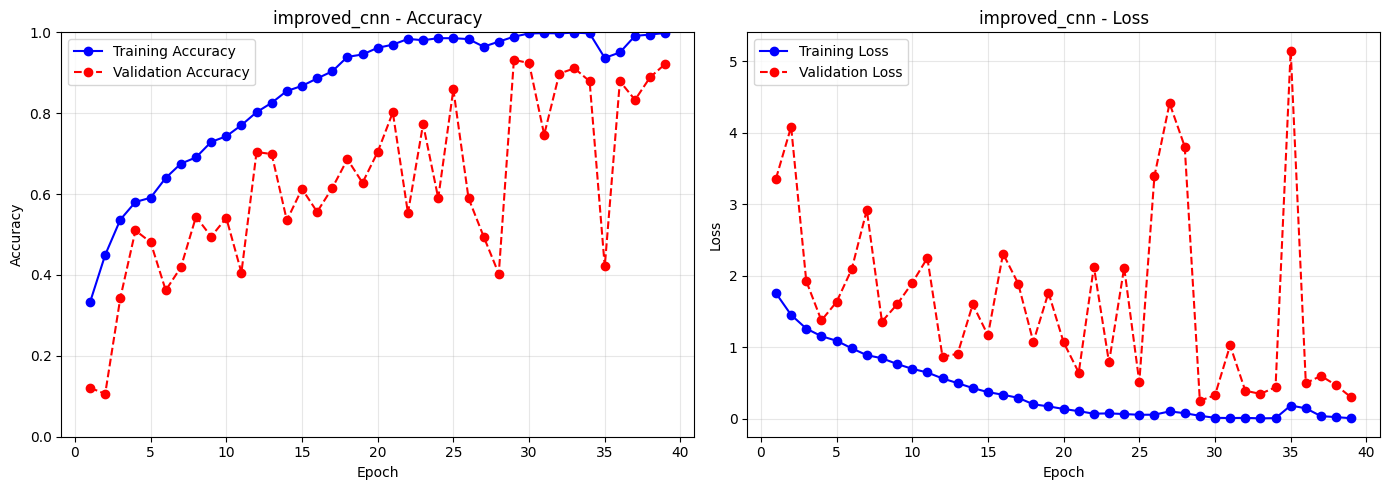

 13/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6876 - loss: 1.1824

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6909 - loss: 1.1668

improved_cnn - Test Accuracy: 0.6965, Test Loss: 1.1427


In [44]:
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_improved = train_and_evaluate(
    improved_model, 'improved_cnn',
    train_dataset, val_dataset, test_dataset, 60
)
results.append(result_improved)

**Observations (Improved CNN):**

_TODO: Compare with the baseline. Has overfitting been reduced? Did accuracy improve? Comment on the effect of data augmentation, batch normalization, and dropout._

---
## 7. Advanced Architecture: Residual Network

We implement a custom **ResNet-style** model with skip connections. Residual connections help with training deeper networks by alleviating the vanishing gradient problem.

**Key idea:** Instead of learning $H(x)$, the network learns the residual $F(x) = H(x) - x$, so the output becomes $F(x) + x$.

In [30]:
def residual_block(x, filters, downsample=False):
    """A residual block with optional downsampling."""
    strides = 2 if downsample else 1
    shortcut = x
    
    # Main path
    x = layers.Conv2D(filters, 3, strides=strides, padding='same', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    
    # Shortcut path: adjust dimensions if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same', kernel_regularizer=keras.regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Add shortcut
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [31]:
def build_custom_resnet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build a custom ResNet-style model."""
    inputs = keras.Input(shape=input_shape)
    
    # Data augmentation
    x = data_augmentation_low(inputs)
    # x = inputs
    # Initial convolution
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Residual blocks
    # x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    # x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    # x = residual_block(x, 128)
    x = residual_block(x, 256, downsample=True)
    # x = residual_block(x, 256)
    
    # Global Average Pooling (replaces Flatten + Dense)
    x = layers.GlobalAveragePooling2D()(x)
    # x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='custom_resnet')
    return model

resnet_model = build_custom_resnet()
resnet_model.summary()

Model: "custom_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 96, 96, 3) │          0 │ input_layer_7[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 96, 96,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 48, 48,    │     18,496 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 48, 48,    │     36,928 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 48, 48,    │      2,112 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 24, 24,    │     73,856 │ activation_10[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 24, 24,    │          0 │ batch_normalizat

 Total params: 1,214,538 (4.63 MB)

 Trainable params: 1,211,786 (4.62 MB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50


W0000 00:00:1774397572.198506     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.204855     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.206030     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.206904     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.207719     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.208625     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.209820     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.210762     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.211770     270 gp

  1/125 ━━━━━━━━━━━━━━━━━━━━ 7:40 4s/step - accuracy: 0.1562 - loss: 2.7174

W0000 00:00:1774397572.607355     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.620741     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.621869     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.623059     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.624536     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.625830     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.627879     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.629645     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397572.631789     266 gp

  2/125 ━━━━━━━━━━━━━━━━━━━━ 52s 427ms/step - accuracy: 0.1797 - loss: 2.6487

...

 81/125 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.2587 - loss: 2.2014  

W0000 00:00:1774397592.743673     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.751150     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.751923     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.752744     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.753586     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.754502     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.755454     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.756641     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397592.757882     266 gp


Epoch 1: val_loss improved from inf to 3.25118, saving model to models/custom_resnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 170ms/step - accuracy: 0.2769 - loss: 2.1173 - val_accuracy: 0.0910 - val_loss: 3.2512 - learning_rate: 0.0010
Epoch 2/50


W0000 00:00:1774397593.514428     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.520873     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.521177     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.521427     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.521705     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.522003     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.522275     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.522626     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774397593.522999     266 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.3759 - loss: 1.7432
Epoch 2: val_loss did not improve from 3.25118
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.3759 - loss: 1.7431 - val_accuracy: 0.1080 - val_loss: 3.5342 - learning_rate: 0.0010
Epoch 3/50
 43/125 ━━━━━━━━━━━━━━━━━━━━ 3:19 2s/step - accuracy: 0.4126 - loss: 1.6689 
Epoch 3: val_loss improved from 3.25118 to 2.55916, saving model to models/custom_resnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.4241 - loss: 1.6456 - val_accuracy: 0.2060 - val_loss: 2.5592 - learning_rate: 0.0010
Epoch 4/50
 79/125 ━━━━━━━━━━━━━━━━━━━━ 1:03 1s/step - accuracy: 0.4640 - loss: 1.5339 
Epoch 4: val_loss improved from 2.55916 to 2.35161, saving model to models/custom_resnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.4636 - loss: 1.5387 - val_accuracy: 0.2850 - val_loss: 2.3516 - learning_rate: 0.0010
Epoch 5/50
  8/125 ━━━━━━━━━━━━━━━━━━━━ 26:59 14s/step - accuracy: 0.4976 - lo

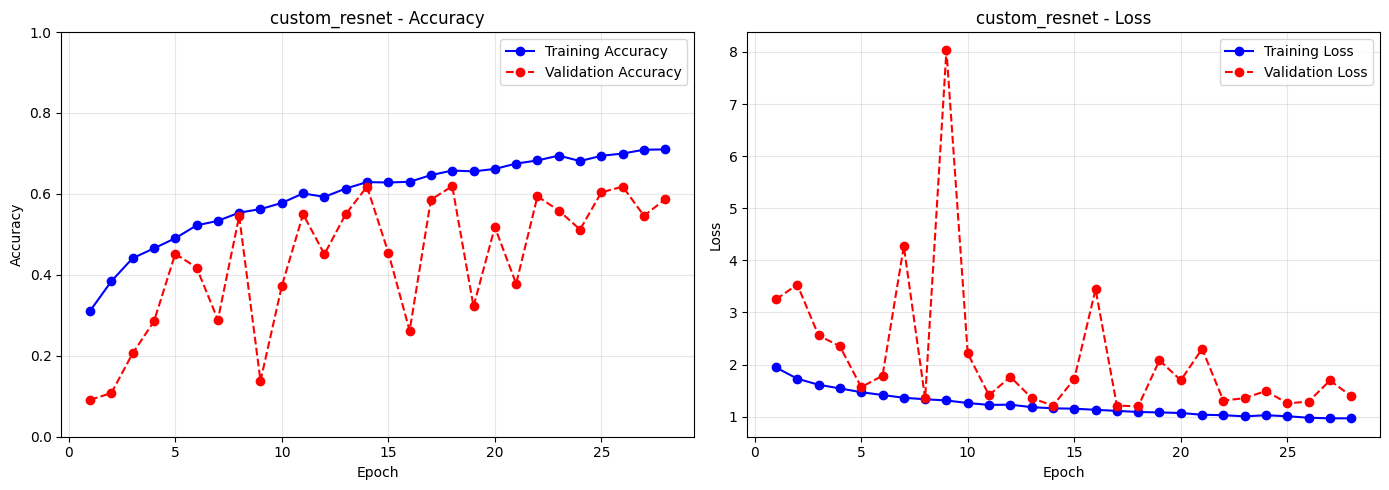

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5764 - loss: 1.3584  

custom_resnet - Test Accuracy: 0.5805, Test Loss: 1.3488


In [32]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_resnet = train_and_evaluate(
    resnet_model, 'custom_resnet',
    train_dataset, val_dataset, test_dataset
)
results.append(result_resnet)

**Observations (Custom ResNet):**

_TODO: Comment on how residual connections affect training. Did the deeper network train well? Compare with previous models._

---
## 8. Advanced Architecture: Inception / Xception

We implement a custom model inspired by **Inception** / **Xception** architectures:
- **Inception module:** Applies multiple filter sizes (1×1, 3×3, 5×5) in parallel and concatenates the outputs.
- **Depthwise separable convolutions** (Xception-style): More parameter-efficient than standard convolutions.

In [33]:
def inception_module(x, filters_1x1, filters_3x3, filters_5x5):
    """A simplified Inception module with parallel convolutions."""
    # 1x1 branch
    branch_1x1 = layers.Conv2D(filters_1x1, 1, padding='same', activation='relu')(x)
    
    # 3x3 branch
    branch_3x3 = layers.Conv2D(filters_3x3, 3, padding='same', activation='relu')(x)
    
    # 5x5 branch
    branch_5x5 = layers.Conv2D(filters_5x5, 5, padding='same', activation='relu')(x)
    
    # Max pooling branch
    branch_pool = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    branch_pool = layers.Conv2D(filters_1x1, 1, padding='same', activation='relu')(branch_pool)
    
    # Concatenate
    output = layers.Concatenate()([branch_1x1, branch_3x3, branch_5x5, branch_pool])
    return output

In [34]:
def build_custom_inception(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build a custom Inception-style model."""
    inputs = keras.Input(shape=input_shape)
    
    # Data augmentation
    x = data_augmentation_low(inputs)
    # x = inputs
    
    # Initial convolution
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Inception modules
    x = inception_module(x, 32, 48, 16)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = inception_module(x, 64, 96, 32)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = inception_module(x, 128, 192, 64)
    x = layers.BatchNormalization()(x)
    
    # Classification
    x = layers.GlobalAveragePooling2D()(x)
    # x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='custom_inception')
    return model

inception_model = build_custom_inception()
inception_model.summary()

Model: "custom_inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 96, 96, 3) │          0 │ input_layer_8[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 96, 96,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 48, 48,    │          0 │ max_pooling2d_17… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 48, 48,    │      1,056 │ max_pooling2d_17… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 48, 48,    │     13,872 │ max_pooling2d_17… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 48, 48,    │     12,816 │ max_pooling2d_17… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 48, 48,    │      1,056 │ max_pooling2d_18… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 48,    │          0 │ conv2d_36[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_37[0][0],  │
│                     │                   │            │ conv2d_38[0][0],  │
│                     │                   │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 24, 24,    │          0 │ max_pooling2d_19… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 24, 24,    │      8,256 │ max_pooling2d_19… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 24, 24,    │    110,688 │ max_pooling2d_19… │
│                     │ 96)               │            │                 

 Total params: 1,314,954 (5.02 MB)

 Trainable params: 1,313,098 (5.01 MB)

 Non-trainable params: 1,856 (7.25 KB)

Epoch 1/50


W0000 00:00:1774398046.456848     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.460133     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.462107     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.463010     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.463605     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.464313     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.465623     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.467069     271 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398046.469683     271 gp

  1/125 ━━━━━━━━━━━━━━━━━━━━ 9:26 5s/step - accuracy: 0.1250 - loss: 2.3175

W0000 00:00:1774398047.078238     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.087222     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.087617     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.087938     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.088350     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.088743     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.089158     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.089767     272 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398047.090253     272 gp

 95/125 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.2849 - loss: 1.9384 

W0000 00:00:1774398059.441733     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.442837     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.443457     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.444111     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.444587     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.445171     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.445982     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.446667     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398059.448155     267 gp


Epoch 1: val_loss improved from inf to 4.57955, saving model to models/custom_inception.keras


W0000 00:00:1774398060.198609     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.199235     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.199705     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.200152     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.200476     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.200791     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.201259     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.201884     266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774398060.202393     266 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.2967 - loss: 1.9007 - val_accuracy: 0.0870 - val_loss: 4.5795 - learning_rate: 0.0010
Epoch 2/50
 67/125 ━━━━━━━━━━━━━━━━━━━━ 1:29 2s/step - accuracy: 0.4040 - loss: 1.5952  
Epoch 2: val_loss did not improve from 4.57955
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.4187 - loss: 1.5542 - val_accuracy: 0.1020 - val_loss: 4.7856 - learning_rate: 0.0010
Epoch 3/50
110/125 ━━━━━━━━━━━━━━━━━━━━ 14s 966ms/step - accuracy: 0.5033 - loss: 1.3234
Epoch 3: val_loss improved from 4.57955 to 2.97993, saving model to models/custom_inception.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.5037 - loss: 1.3242 - val_accuracy: 0.1730 - val_loss: 2.9799 - learning_rate: 0.0010
Epoch 4/50
 95/125 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5409 - loss: 1.2280 
Epoch 4: val_loss improved from 2.97993 to 2.04784, saving model to models/custom_inception.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.5405 

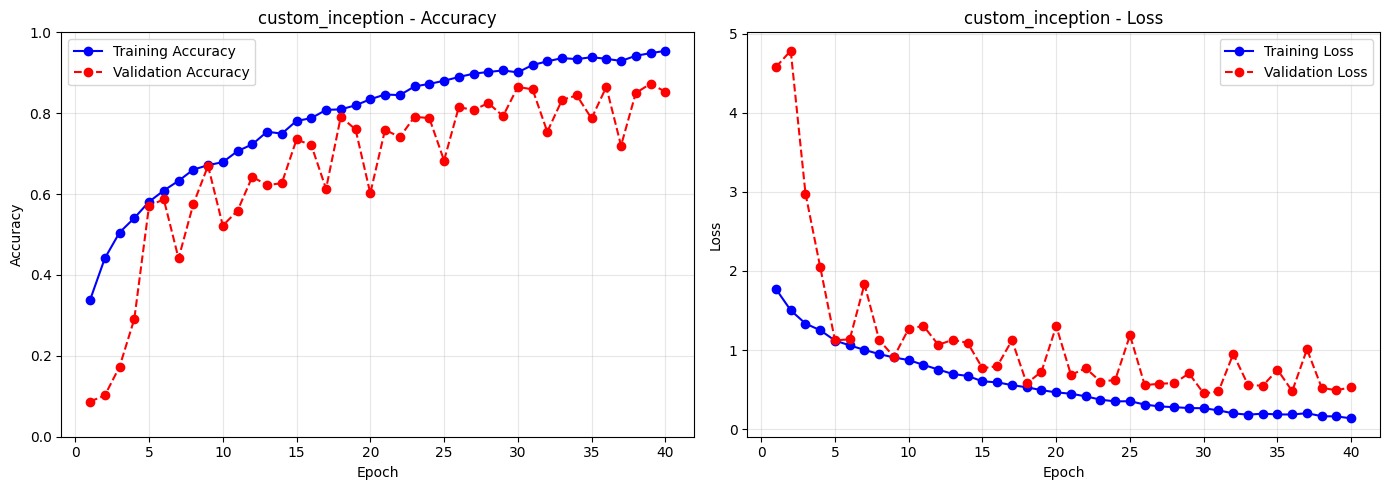

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6714 - loss: 1.2261

custom_inception - Test Accuracy: 0.6709, Test Loss: 1.2095


In [35]:
inception_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_inception = train_and_evaluate(
    inception_model, 'custom_inception',
    train_dataset, val_dataset, test_dataset
)
results.append(result_inception)

**Observations (Custom Inception):**

_TODO: Comment on the multi-scale feature extraction. How does this compare with the ResNet and improved CNN? Discuss parameter efficiency._

---
## 9. Results Comparison

Summary of all custom CNN models trained.

In [36]:
import pandas as pd

# Build comparison table
comparison_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test Loss': f"{r['test_loss']:.4f}"
    }
    for r in results
])

print("\n" + "="*60)
print("RESULTS SUMMARY - Custom CNNs")
print("="*60)
display(comparison_df)


RESULTS SUMMARY - Custom CNNs


,Model,Test Accuracy,Test Loss
0,baseline_a_2blocks,0.5244,2.4296
1,baseline_b_3blocks,0.5740,1.8288
2,baseline_c_4blocks,0.5709,1.6945
3,baseline_d_double_conv,0.4927,2.1760
4,improved_cnn,0.6984,1.0272
5,custom_resnet,0.5805,1.3488
6,custom_inception,0.6709,1.2095


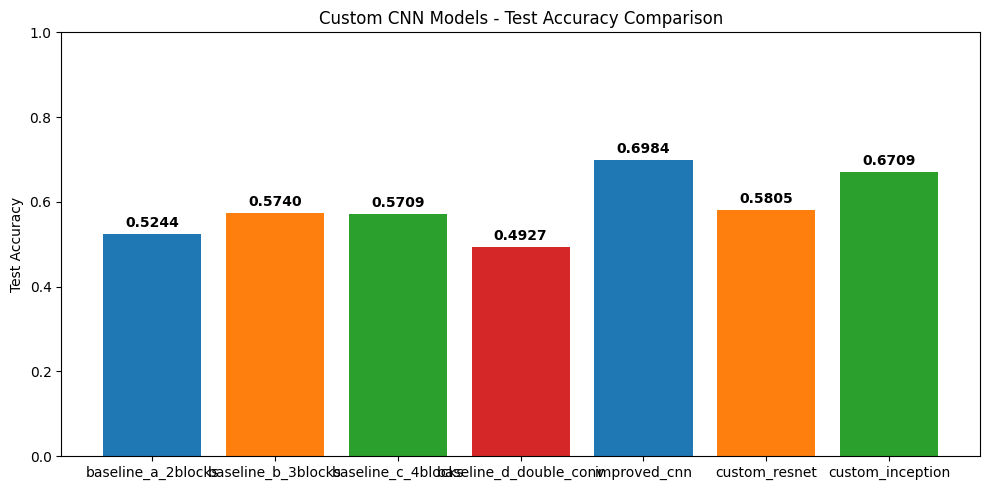

In [37]:
# Bar chart comparison
model_names = [r['model_name'] for r in results]
test_accs = [r['test_accuracy'] for r in results]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, test_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylabel('Test Accuracy')
plt.title('Custom CNN Models - Test Accuracy Comparison')
plt.ylim(0, 1)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
import glob

def evaluate_best_models(models_dir, test_dataset):
    """
    Loads all saved .keras models from a directory, evaluates them 
    against the test set, and plots the final accuracies.
    """
    # Grab all .keras files (change to .h5 if using the older Keras 2 format)
    model_paths = glob.glob(os.path.join(models_dir, "*.keras"))
    
    if not model_paths:
        print(f"No models found in '{models_dir}'. Check your path!")
        return

    model_names = []
    test_accuracies = []

    print("Starting evaluation pipeline...")
    for path in model_paths:
        # Get a clean name for the plot (e.g., 'baseline_cnn' instead of 'baseline_cnn.keras')
        name = os.path.basename(path).replace('.keras', '')
        print(f"Evaluating {name}...")
        
        try:
            # Load the model, safely handling the custom augmentation layer
            model = keras.models.load_model(
                path, 
                custom_objects={"CustomColorJitter": CustomColorJitter}
            )
            
            # evaluate() returns [loss, accuracy] assuming you compiled with metrics=['accuracy']
            metrics = model.evaluate(test_dataset, verbose=0)
            
            # In Keras, loss is typically index 0, accuracy is index 1
            accuracy = metrics[1] 
            
            model_names.append(name)
            test_accuracies.append(accuracy)
            
        except Exception as e:
            print(f"  -> Failed to load or evaluate {name}. Error: {e}")
            continue

    # --- Plotting the Results ---
    if not model_names:
        print("No models were successfully evaluated.")
        return

# --- NEW: Sorting Logic ---
    # Zip combines them into pairs: (accuracy, name)
    # sorted() automatically sorts by the first element of the tuple (accuracy)
    sorted_pairs = sorted(zip(test_accuracies, model_names))
    
    # Unzip back into two separate lists
    test_accuracies, model_names = zip(*sorted_pairs)
    
    # Convert tuples back to lists (matplotlib prefers lists/arrays)
    test_accuracies = list(test_accuracies)
    model_names = list(model_names)

    plt.figure(figsize=(10, 6))
    
    # Create the bar chart with a nice aesthetic color
    bars = plt.bar(model_names, test_accuracies, color='#4C72B0', edgecolor='black')
    
    # Formatting the plot
    plt.title('Final Test Set Accuracy on STL-10', fontsize=14, fontweight='bold')
    plt.xlabel('Model Architecture', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0) # Lock Y-axis from 0 to 100%
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') # Tilt labels if model names are long
    
    # Add the exact accuracy numbers on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            yval + 0.02, 
            f'{yval:.3f}', 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            fontweight='bold'
        )
        
    plt.tight_layout()
    plt.show()

Starting evaluation pipeline...
Evaluating baseline_d_double_conv...


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Evaluating baseline_b_3blocks...


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Evaluating baseline_c_4blocks...


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Evaluating improved_cnn...
Evaluating custom_resnet...
Evaluating baseline_a_2blocks...


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Evaluating custom_inception...
Evaluating baseline_cnn...


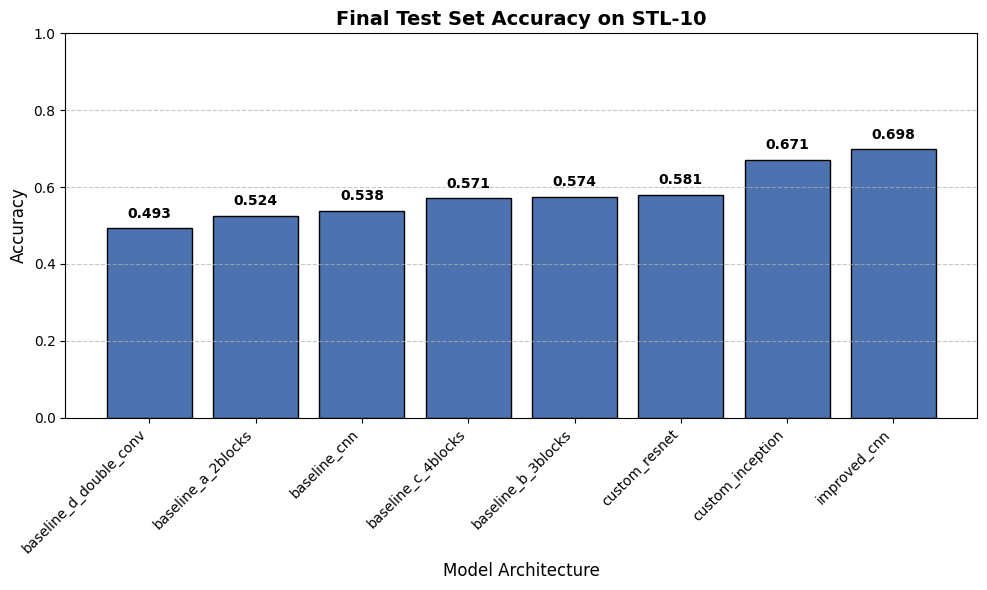

In [39]:
evaluate_best_models("./models", test_dataset)

---
## 10. Conclusions

_TODO: Write a comprehensive comparison of all custom CNN models:_

- _Which model achieved the best accuracy and why?_
- _How did regularization techniques (data augmentation, dropout, batch normalization) affect the results?_
- _What are the advantages and disadvantages of each architecture (simple CNN vs ResNet vs Inception)?_
- _What are the main challenges when working with a small dataset like STL-10?_
- _What improvements could be made in future iterations?_